## Initialization


In [2]:
# === Data handling ===
import pandas as pd
import numpy as np

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# === TensorFlow / Keras ===
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import load_img, img_to_array

# === Utils ===
import inspect

## Load the Data


The dataset is stored in the `./` folder.
- The `final_files` folder contains 7,600 photos.
- The `labels.csv` file contains the labels, with two columns: `file_name` and `real_age`.

Since the number of image files is quite large, it is recommended to avoid reading them all at once, as this would consume many computational resources. We recommend creating a generator with `ImageDataGenerator`. This method was explained in Chapter 3, Lesson 7 of this course.

The label file can be loaded as a regular CSV file.


In [3]:
path = './'

labels = pd.read_csv(path + 'labels.csv')
labels.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [4]:
labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   file_name  7591 non-null   str  
 1   real_age   7591 non-null   int64
dtypes: int64(1), str(1)
memory usage: 118.7 KB


In [5]:
print("Número total de imágenes:", labels.shape[0])
print("Null values:\n", labels.isna().sum())

Número total de imágenes: 7591
Null values:
 file_name    0
real_age     0
dtype: int64


In [6]:
def load_data(path, subset='training'):
    labels = pd.read_csv(path + 'labels.csv')

    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=0.2  # splits train/validation from labels.csv
    )

    gen = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset=subset,
        seed=12345
    )
    return gen

train_gen = load_data(path, subset='training')
test_gen  = load_data(path, subset='validation')

Found 6073 validated image filenames.
Found 1518 validated image filenames.


- The dataset was loaded correctly from the `./` path.
- The `labels.csv` file contains 7,591 records, each associated with an image and its real age (`real_age`).

- No null values or inconsistencies were detected in the columns, which indicates good initial data quality and avoids the need for additional cleaning at this stage.

- Given the large number of images, `ImageDataGenerator` was used to load the data efficiently in memory, avoiding reading all images simultaneously.
- Pixel value normalization (`rescale=1/255`) and an automatic training/validation split using `validation_split=0.2` were applied.

As a result:
- 6,073 images were assigned to the training set.
- 1,518 images were assigned to the validation set.

This strategy allows more efficient training and proper model evaluation, reducing the risk of overfitting and maintaining a reproducible data flow.


## EDA - Initial Data Analysis
### Dataset Size and Age Statistics


In [7]:
print("Train batches:", len(train_gen))
print("Val batches:", len(test_gen))

print("Age - min:", labels["real_age"].min())
print("Age - max:", labels["real_age"].max())
print("Age - mean:", labels["real_age"].mean())
print("Age - median:", labels["real_age"].median())

Train batches: 190
Val batches: 48
Age - min: 1
Age - max: 100
Age - mean: 31.20115926755368
Age - median: 29.0


### Age Distribution


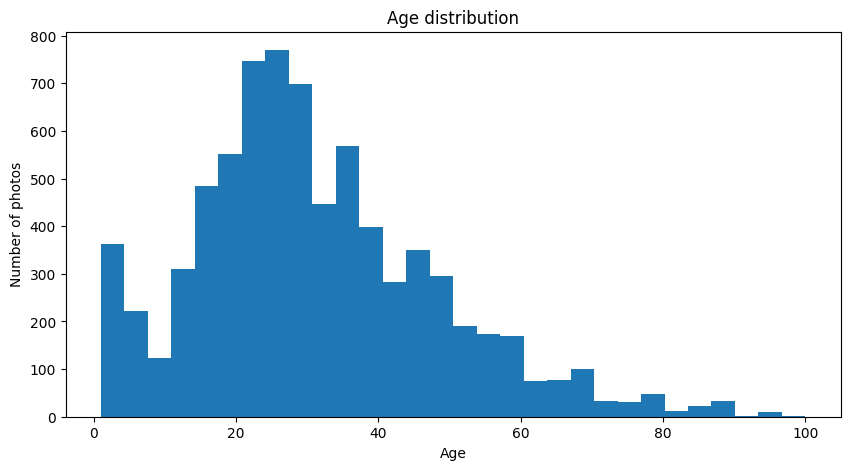

In [8]:
plt.figure(figsize=(10,5))
plt.hist(labels["real_age"], bins=30)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Number of photos")
plt.show()

### Sample Photos with Age


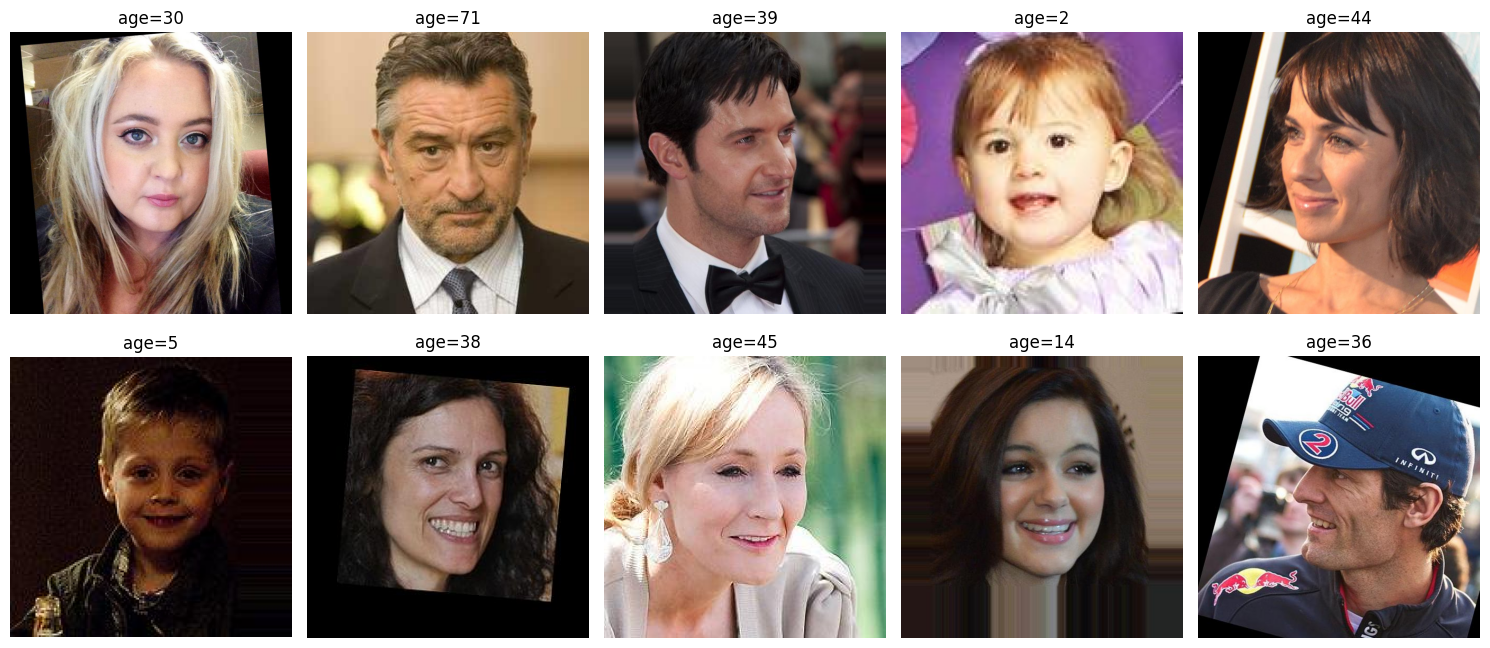

In [9]:
sample = labels.sample(10, random_state=123)

plt.figure(figsize=(15,10))
for i, row in enumerate(sample.itertuples(index=False), 1):
    img_path = path + "final_files/" + row.file_name
    img = mpimg.imread(img_path)

    plt.subplot(3, 5, i)
    plt.imshow(img)
    plt.title(f"age={row.real_age}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Conclusions

- The dataset contains 7,591 images labeled with real age, with no null values or inconsistencies in the `file_name` and `real_age` variables, which indicates good initial data quality.
- Ages range from 1 to 100 years, with a mean of 31.2 years and a median of 29 years, showing a slight skew toward older ages.

- The age distribution is not uniform: there is a high concentration between 20 and 40 years old, while the extremes (very young children and older adults) are less represented. This may introduce bias into the model, affecting its accuracy for less frequent ages.

- The training and validation sets were correctly split using `ImageDataGenerator` with `validation_split=0.2`, resulting in:
  - 190 training batches
  - 48 validation batches

- Visual inspection of a random sample of images confirms that:
  - The photos show high variability in lighting, poses, facial expressions, and quality.
  - The assigned ages appear consistent with the images, which supports the reliability of the labels.

Given the distribution and visual complexity of the dataset, it is appropriate to approach the problem as a regression task and use a pretrained deep model such as ResNet50 to capture high-level visual patterns.

Overall, the exploratory analysis suggests that the dataset is suitable for training a computer vision model, although it will be important to monitor overfitting and carefully evaluate performance on underrepresented ages.


## Modeling


Define the functions needed to train the model on the GPU platform and create a single script that contains all of them together with the initialization section.

To make this task easier, you can define them in this notebook and run ready-to-use code in the next section to automatically compose the script.

The project reviewers will also check the definitions below so they can understand how the model was built.


#### Preprocessing and Train/Validation Split


In [10]:
path = "./"

labels = pd.read_csv(path + "labels.csv")

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = datagen.flow_from_dataframe(
    dataframe=labels,
    directory=path + "final_files/",
    x_col="file_name",
    y_col="real_age",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    subset="training",
    seed=12345,
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    dataframe=labels,
    directory=path + "final_files/",
    x_col="file_name",
    y_col="real_age",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    subset="validation",
    seed=12345,
    shuffle=False
)

Found 6073 validated image filenames.
Found 1518 validated image filenames.


- In this section, the model input pipeline is built.
- The images and their labels (real age) are loaded from disk using `ImageDataGenerator`, applying the preprocessing required for the data to be compatible with a pretrained ResNet50 network.
- In addition, the dataset is split into training and validation sets (80/20) so the model's generalization ability can be evaluated during training.

- `ImageDataGenerator` is used to load images by batches, which enables efficient memory usage and facilitates GPU training. It also automatically manages the split between training and validation.

- `flow_from_dataframe` allows each image to be associated with its corresponding label stored in a CSV file, making it possible to train the model on a supervised regression task (age prediction).
- The training generator uses shuffling to improve model generalization, while the validation generator does not shuffle the data to ensure consistent evaluation.

At this stage, the model data pipeline is defined. It is responsible for loading the images, applying the appropriate preprocessing, linking them with their real age, and splitting the dataset into training and validation.


In [11]:
# Verificación del generador de entrenamiento

x, y = next(train_gen)
print(x.shape, y.shape)
print("x min/max:", x.min(), x.max())
print("y min/max:", y.min(), y.max())

(32, 224, 224, 3) (32,)
x min/max: -123.68 151.061
y min/max: 9 69


#### Result Interpretation
32 is the batch size.
224 x 224 is the resolution of each image.
3 is the number of RGB channels.
(32,) is one age value per image.

#### Code Interpretation
This cell inspects a batch of data generated by `train_gen` to validate that the images and labels have the expected format.
- `x` contains a batch of images with shape `(batch_size, height, width, channels)`, while `y` contains the real ages associated with each image.
- The minimum and maximum values of `x` confirm that ResNet50's `preprocess_input` has been applied correctly, and the values of `y` show an age range consistent with the regression problem.

This cell is important because it answers three critical questions before training:
- Do the images have the correct shape?
- Is the preprocessing compatible with ResNet50?
- Do the labels have consistent values?

If something here were wrong, the model could train without raising an error, but the quality of the results would not be appropriate.


#### Model Definition and Architecture

In this section, the architecture of the regression model responsible for predicting age from facial images is defined. The approach used is transfer learning, relying on a deep pretrained convolutional network.


In [12]:
def create_model(input_shape=(224, 224, 3), lr=1e-4):
    backbone = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape )
    backbone.trainable = False  # first train only the model head

    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(1)  # regression: age
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model

model = create_model((224, 224, 3), lr=1e-4)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#### Result Interpretation
- The vast majority of parameters belong to the frozen backbone.
- Only 262k parameters are trainable, corresponding to the model head.
This confirms that training focuses on adjusting the age prediction, not on relearning basic visual features.

#### Code Interpretation
#### Backbone: Pretrained ResNet50
- ResNet50 is used, a deep convolutional network previously trained on ImageNet.
  - `include_top=False` removes the original final classification layers.
  - This allows the model to reuse general visual features (edges, textures, facial patterns) learned during pretraining.

#### Freezing the Backbone
- In this first stage, the backbone weights are frozen and only the added layers ("the model head") are trained. This:
  - Reduces the risk of overfitting
  - Speeds up training
  - Is ideal when the dataset is not extremely large

#### Regression Head
Components:
- `GlobalAveragePooling2D`:
  - Reduces the feature map `(7, 7, 2048)` to a 2048-dimensional vector.
  - Decreases the number of parameters and improves generalization.

- `Dense(128, ReLU)`:
  - Learns nonlinear combinations of the extracted features.
  - Acts as a semantic interpretation layer.

- `Dropout(0.2)`:
  - Applies regularization.
  - Reduces overfitting by randomly turning off neurons during training.

- `Dense(1)`:
  - Final output layer.
  - Produces a continuous value: the predicted age.

No activation function is used because this is a regression problem.

#### Model Compilation
- Optimizer: Adam with `learning_rate = 1e-4` for stable learning.
- Loss function: MSE (Mean Squared Error), which penalizes large errors more strongly.
- Metric: MAE (Mean Absolute Error), the main project metric and easy to interpret in years.


### Model Training and Evaluation

This is the final phase of controlled training and model evaluation, incorporating an early stopping mechanism to avoid overtraining and optimize the use of computational resources.


In [13]:
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

loss, mae = model.evaluate(val_gen, verbose=1)
print("Final MAE:", mae)

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - loss: 420.2394 - mae: 15.6981 - val_loss: 257.4029 - val_mae: 12.7160
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - loss: 249.3811 - mae: 12.1882 - val_loss: 196.5700 - val_mae: 11.2883
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - loss: 212.6698 - mae: 11.2679 - val_loss: 170.0997 - val_mae: 10.3589
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - loss: 196.6343 - mae: 10.8308 - val_loss: 161.7028 - val_mae: 10.2363
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - loss: 189.1883 - mae: 10.6261 - val_loss: 154.3710 - val_mae: 9.9653
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - loss: 180.9522 - mae: 10.4029 - val_loss: 149.8663 - val_mae: 9.8049
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - loss: 176.3149 - mae: 10.2622 - val_loss: 145.5424 - val_mae: 9.4968
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - loss: 171.7178 - mae: 10.1531 - val_loss: 142.6422 - val_mae: 9.5059
Epoc

**Early stopping**
- `monitor='val_mae'`: Monitors the validation mean absolute error, which is the main metric of the problem (age regression).
- `patience=3`: Allows up to 3 consecutive epochs without improvement before stopping training.
- `restore_best_weights=True`: At the end, the model automatically restores the weights from the best epoch, not from the last one.

This is important because it avoids continuing training when the model is no longer improving and reduces the risk of overfitting.


In [14]:
model.save("age_model.keras")

In [15]:
from tensorflow.keras.models import load_model

model = load_model("age_model.keras")

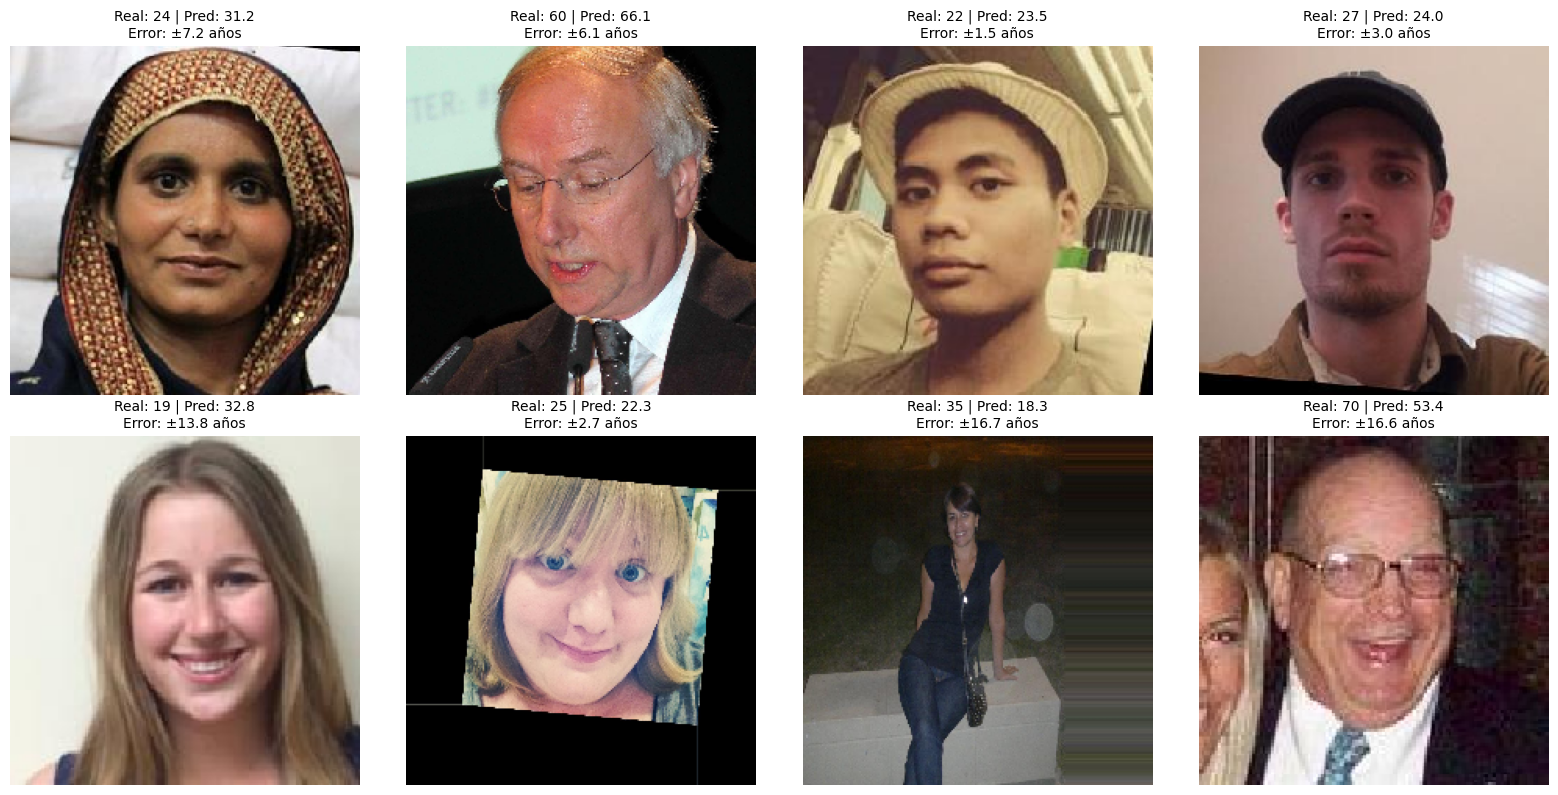

In [16]:
from tensorflow.keras.utils import load_img, img_to_array

def predict_sample_images(model, generator, n=8, seed=123):
    rng = np.random.default_rng(seed)
    sample_indices = rng.choice(len(generator.filepaths), size=n, replace=False)

    images = []
    real_ages = []
    filepaths = []

    for idx in sample_indices:
        img_path = generator.filepaths[idx]

        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)

        images.append(img_array)
        real_ages.append(generator.labels[idx])
        filepaths.append(img_path)

    model_input = preprocess_input(np.array(images).copy())
    predicted_ages = model.predict(model_input, verbose=0).ravel()

    plt.figure(figsize=(16, 8))

    for i, (img_array, real_age, predicted_age, img_path) in enumerate(
        zip(images, real_ages, predicted_ages, filepaths), 1
    ):
        error = abs(predicted_age - real_age)

        plt.subplot(2, 4, i)
        plt.imshow(img_array.astype("uint8"))
        plt.title(
            f"Real: {real_age:.0f} | Pred: {predicted_age:.1f}\n"
            f"Error: ±{error:.1f} años",
            fontsize=10
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

predict_sample_images(model, val_gen, n=8, seed=789)


### The Result


## Project Conclusions

In this project, a **computer vision model for age estimation from facial images** was developed and trained using a *deep learning* architecture based on **ResNet50** with *transfer learning*. The main objective was to evaluate whether an approach of this type is viable for predicting a person's age with an acceptable level of error in a practical context.

The model was trained using previously preprocessed and labeled images, applying standard techniques such as normalization, splitting into training and validation sets, and data augmentation. To improve training efficiency and stability, a network pretrained on ImageNet was used, initially freezing its convolutional layers and training only the model "head" for the regression task.

The model's best performance reached an approximate **MAE (Mean Absolute Error) of 8.9 years** on the validation set. This result indicates that, on average, the model's prediction differs by around eight years from the real age, which is consistent with expected results in age estimation tasks from facial images, considering the visual variability between people.

In conclusion, the project demonstrates that **computer vision can be a useful tool for estimating demographic attributes such as age**, although with certain accuracy limitations. This type of model can be especially valuable as a support system or initial filtering system, but I believe it should not be used as the only decision source in critical contexts.

### Can computer vision help the client in this case?

Yes. A model of this type can help the client to:

- Automate age estimation at scale.
- Classify users into approximate age ranges.
- Reduce operational costs in manual visual verification tasks.
- Detect possible inconsistencies between declared age and estimated age.

### Other practical tasks the model could solve

In addition to age estimation, the client could extend this approach to:

- Classify people by age ranges (children, young people, adults).
- Perform aggregate demographic analysis for market research.
- Integrate with other computer vision models (for example, gender detection or facial expression detection).
- Use it as a support component in recommendation or access control systems.
